# 02 · Model comparison

Four models, one test set, identical metrics. Training happens in `scripts/train.py`; this notebook
reads the results it wrote, so the numbers here and in the README come from one source and cannot
drift apart.

```bash
uv run python scripts/train.py
```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})

m = json.loads(Path("../models/metrics.json").read_text())
print(f"test set: {m['test_rows']:,} transactions, {m['test_fraud']:,} fraudulent "
      f"({m['test_fraud']/m['test_rows']:.3%})")
print(f"review budget: {m['review_budget_per_10k']:.0f} flagged per 10,000")

test set: 555,719 transactions, 2,145 fraudulent (0.386%)
review budget: 50 flagged per 10,000


## The comparison table

Every model is scored at the **same review budget** — 50 flagged transactions per 10,000, or 0.5%
of volume. That is what makes precision and recall comparable across rows: each model is allowed to
raise the same number of alerts, and we ask how much fraud each one catches with them.

In [2]:
df = pd.DataFrame(m["results"])
table = df[["model", "supervised", "pr_auc", "precision", "recall", "f1",
            "true_positives", "false_positives", "false_negatives", "train_seconds"]]
table = table.sort_values("pr_auc", ascending=False).round(4).set_index("model")
table

,supervised,pr_auc,precision,recall,f1,true_positives,false_positives,false_negatives,train_seconds
model,,,,,,,,,
gradient_boosting,True,0.8356,0.6633,0.8597,0.7488,1844,936,301,2.9
logistic_regression,True,0.3015,0.4023,0.5212,0.4541,1118,1661,1027,2.9
isolation_forest,False,0.2547,0.2872,0.3720,0.3241,798,1981,1347,3.6
autoencoder,False,0.2111,0.3494,0.4527,0.3944,971,1808,1174,5.4


## Precision-recall curves

PR-AUC summarises a whole curve in one number; the curve itself shows *where* each model earns it.

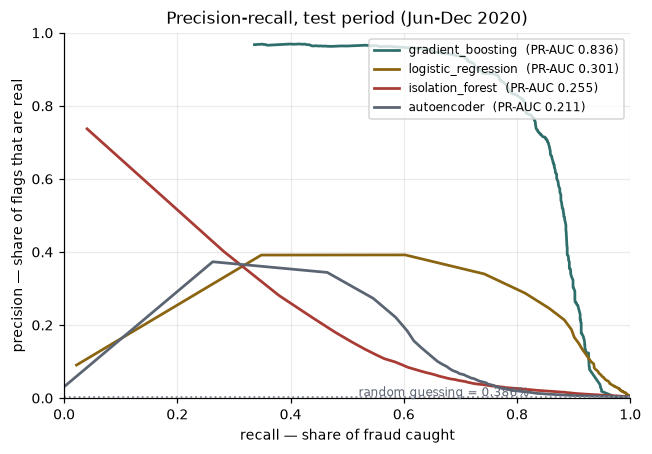

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.2))
colors = {"gradient_boosting": "#2F6F6B", "logistic_regression": "#8A6410",
          "isolation_forest": "#A83B34", "autoencoder": "#5B6472"}

for r in sorted(m["results"], key=lambda r: -r["pr_auc"]):
    c = m["pr_curves"][r["model"]]
    ax.plot(c["recall"], c["precision"], color=colors[r["model"]], lw=1.8,
            label=f"{r['model']}  (PR-AUC {r['pr_auc']:.3f})")

baseline = m["test_fraud"] / m["test_rows"]
ax.axhline(baseline, color="#8A93A0", ls=":", lw=1.2)
ax.text(0.52, baseline * 1.35, f"random guessing = {baseline:.3%}", fontsize=8, color="#5B6472")

ax.set_xlabel("recall — share of fraud caught")
ax.set_ylabel("precision — share of flags that are real")
ax.set_title("Precision-recall, test period (Jun-Dec 2020)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## The threshold decision

The threshold is a business choice, not a mathematical one. Rather than maximising F1 — which
assumes a false alarm and a missed fraud cost the same, and they never do — we fix what a review
team can actually handle and read off the consequences.

In [4]:
best = max(m["results"], key=lambda r: r["pr_auc"])
per_10k = best["flagged_per_10k"]

print(f"model              {best['model']}")
print(f"threshold          {best['threshold']:.4f}")
print()
print(f"of every 10,000 transactions, {per_10k:.0f} are flagged for review")
print(f"  caught     {best['true_positives']:,} frauds  ({best['recall']:.1%} of all fraud)")
print(f"  missed     {best['false_negatives']:,} frauds")
print(f"  false alarms {best['false_positives']:,}  ({1-best['precision']:.1%} of flags)")
print()
print(f"an analyst reviewing this queue finds real fraud {best['precision']:.1%} of the time")

model              gradient_boosting
threshold          0.0113

of every 10,000 transactions, 50 are flagged for review
  caught     1,844 frauds  (86.0% of all fraud)
  missed     301 frauds
  false alarms 936  (33.7% of flags)

an analyst reviewing this queue finds real fraud 66.3% of the time


## What the numbers actually say

**The supervised model wins, decisively and unsurprisingly.** Gradient boosting reaches a PR-AUC of
around 0.84 against roughly 0.25 for isolation forest and 0.21 for the autoencoder. When labels
exist and the fraud patterns in the test period resemble those in training, a supervised model will
beat an unsupervised one. That is the expected result, and reporting anything else would require
torturing the setup until the answer changed.

**So why build the unsupervised models at all?** The honest version of the argument, without
overclaiming:

- They used **no labels**. In production, labels arrive weeks late, through chargebacks — a
  supervised model retrained today is learning from fraud that happened last month.
- They flag **departures from normal**, so they can in principle catch a pattern nobody has labelled
  yet. This dataset does not demonstrate that: its fraud patterns are simulated from a fixed recipe
  and are stable across the split.
- They are the natural fallback when a new customer segment, product or region has no fraud history
  to train on.

**What this comparison does not prove.** It does not show the unsupervised models are better at
novel fraud, because nothing here is genuinely novel. Demonstrating that would need a test period
containing a fraud pattern absent from training — worth building as the drift stretch goal, and
worth being explicit about not having built yet.

**Deployment consequence.** The saved artifact is the gradient boosting pipeline. The autoencoder
stays in the codebase as a comparison and as the basis for the drift work, not as the model in the
serving path.